## ◉ Multi Stage Training
2 Stage Training of Yolo on [VCoR Dataset](https://www.kaggle.com/datasets/landrykezebou/vcor-vehicle-color-recognition-dataset/data)

```{note}
:class: full-width
BTW… a 2 stage training is not really needed for such a small dataset - its just an experiment
```

In [67]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from PIL import Image
import random
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from ultralytics.models.yolo import YOLO
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    top_k_accuracy_score,
)
import seaborn as sns

Load the VCoR dataset

In [27]:
DATASET_ROOT = Path("vcor/")
CLASS_NAMES = sorted(os.listdir(DATASET_ROOT / "train"))
print(f"Number of classes: {len(CLASS_NAMES)}")
print(f"Classes: {CLASS_NAMES}")

Number of classes: 15
Classes: ['beige', 'black', 'blue', 'brown', 'gold', 'green', 'grey', 'orange', 'pink', 'purple', 'red', 'silver', 'tan', 'white', 'yellow']


class distribution for splits (training, validation, test)

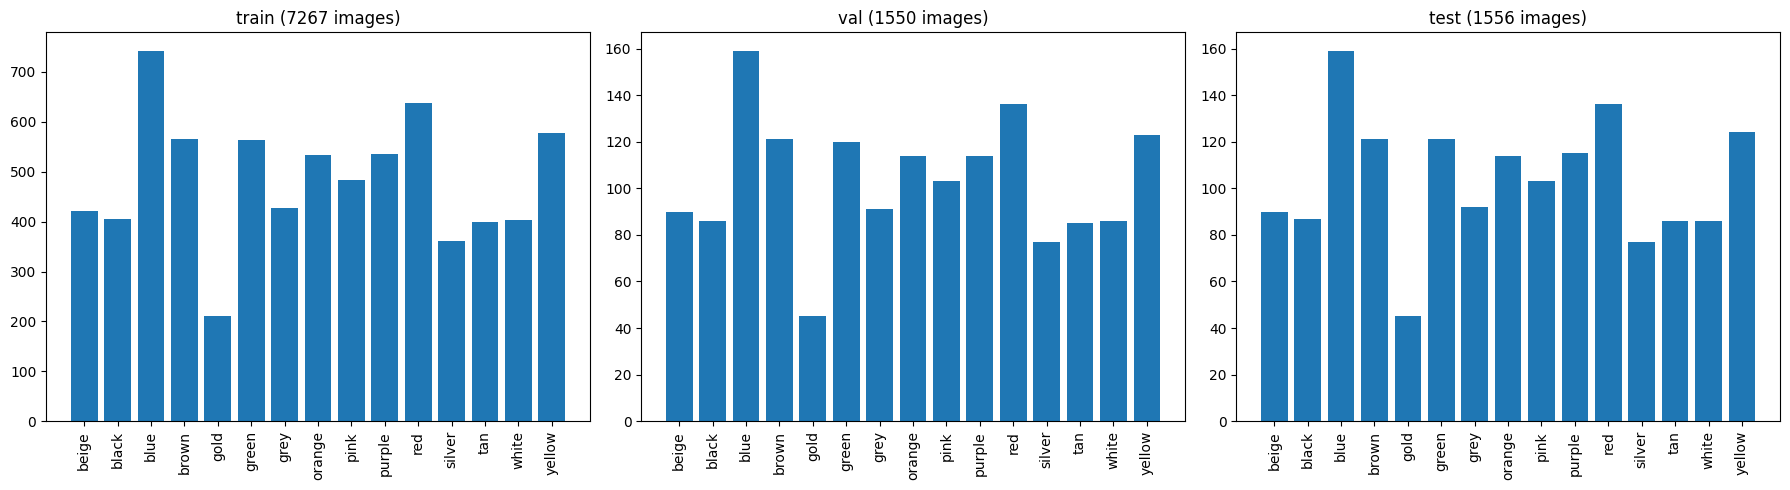

In [31]:
def count_samples(split_dir):
    counts = {}
    for cls in CLASS_NAMES:
        cls_dir = split_dir / cls
        counts[cls] = len(list(cls_dir.glob("*"))) if cls_dir.exists() else 0
    return counts

splits = ["train", "val", "test"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, split in zip(axes, splits):
    counts = count_samples(DATASET_ROOT / split)
    ax.bar(counts.keys(), counts.values())
    ax.set_title(f"{split} ({sum(counts.values())} images)")
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

sample images

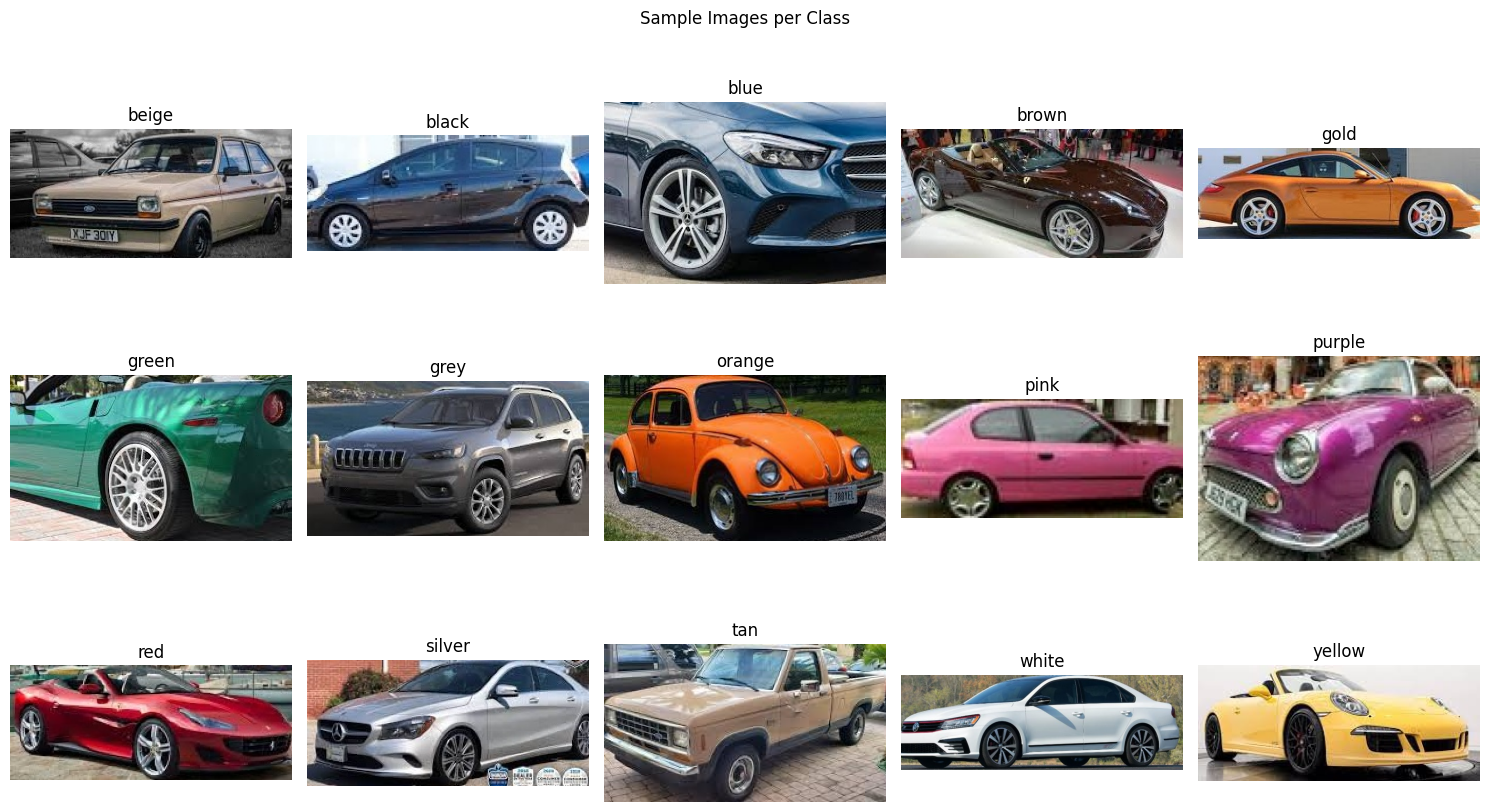

In [35]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, cls in enumerate(CLASS_NAMES):
    imgs = list((DATASET_ROOT / "train" / cls).glob("*"))
    img = Image.open(random.choice(imgs))
    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()

define transforms pipeline for training and validation

In [37]:
IMG_SIZE = 320

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


Create training, test and validation DataLoader

In [40]:
train_dataset = ImageFolder(root=DATASET_ROOT / "train", transform=train_transforms)
val_dataset   = ImageFolder(root=DATASET_ROOT / "val",   transform=val_test_transforms)
test_dataset  = ImageFolder(root=DATASET_ROOT / "test",  transform=val_test_transforms)

print("Class to Index:", train_dataset.class_to_idx)

Class to Index: {'beige': 0, 'black': 1, 'blue': 2, 'brown': 3, 'gold': 4, 'green': 5, 'grey': 6, 'orange': 7, 'pink': 8, 'purple': 9, 'red': 10, 'silver': 11, 'tan': 12, 'white': 13, 'yellow': 14}


In [44]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_dataset)} \nVal: {len(val_dataset)} \nTest: {len(test_dataset)}")

Train: 7267 
Val: 1550 
Test: 1556


### Model
use Yolo backbone for feature extraction and replace the final head with a linear classifier for 15 color classes

In [48]:
base_model = YOLO("yolov8m-cls.pt")
NUM_CLASSES = 15

model = base_model.model.model  

classifer_head = model[-1]
print("Original Classifier Head:", classifer_head)

Original Classifier Head: Classify(
  (conv): Conv(
    (conv): Conv2d(768, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Linear(in_features=1280, out_features=1000, bias=True)
)


mutate the linear layer to create 15 class as output

In [49]:
in_features = classifer_head.linear.in_features
classifer_head.linear = nn.Linear(in_features, NUM_CLASSES)
print("Modified Classifier Head:", classifer_head)

Modified Classifier Head: Classify(
  (conv): Conv(
    (conv): Conv2d(768, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (pool): AdaptiveAvgPool2d(output_size=1)
  (drop): Dropout(p=0.0, inplace=True)
  (linear): Linear(in_features=1280, out_features=15, bias=True)
)


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
full_model = base_model.model.to(device)
print(f"Using device: {device}")
print(f"Total params: {sum(p.numel() for p in full_model.parameters()):,}")
full_model

Using device: cuda
Total params: 15,791,551


ClassificationModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
  

### Training Setup

In [64]:
# Hyperparameters
EPOCHS = 30
LR = 1e-3
WEIGHT_DECAY = 5e-4  

optimizer = AdamW(full_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
loss_fn = nn.CrossEntropyLoss() 

In [53]:
def train_one_epoch(model, dataloader, optimizer, loss_fn, device):
    # set the model in training mode
    model.train() 
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, dataloader, loss_fn, device):
    model.eval() 
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        
        loss = loss_fn(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


### 2 Stage training

Stage 1: freeze backbone, train only classification head

In [54]:
STAGE1_EPOCHS = 20
STAGE1_LR = 1e-3

# freeze backbone
for name, param in full_model.named_parameters():
    param.requires_grad = False
# Unfreeze only the classify head
for param in model[-1].parameters():
    param.requires_grad = True

In [59]:
trainable = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
total = sum(p.numel() for p in full_model.parameters())
print(f"Stage 1 \n--> Trainable params: {trainable:,} (head) / {total:,} (total) \n--> i.e. trainable params ({100*trainable/total:.1f}%)")

Stage 1 
--> Trainable params: 1,004,815 (head) / 15,791,551 (total) 
--> i.e. trainable params (6.4%)


In [ ]:
optimizer_s1 = AdamW(filter(lambda p: p.requires_grad, full_model.parameters()),
                     lr=STAGE1_LR, weight_decay=WEIGHT_DECAY)
scheduler_s1 = CosineAnnealingLR(optimizer_s1, T_max=STAGE1_EPOCHS, eta_min=1e-5)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "stage": []}
best_val_acc = 0.0

print("\n--- Stage 1: Head-only training ---")
for epoch in range(STAGE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(full_model, train_loader,
                                             optimizer_s1, loss_fn, device)
    val_loss, val_acc = evaluate(full_model, val_loader, loss_fn, device)
    scheduler_s1.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["stage"].append(1)

    print(f"  S1 Epoch [{epoch+1}/{STAGE1_EPOCHS}] "
          f"Train: {train_loss:.4f} (loss) / {train_acc:.2f}% (acc) | "
          f"Val: {val_loss:.4f} (loss) / {val_acc:.2f}% (acc)")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(full_model.state_dict(), "best_vcor_yolo_cls.pt")
        print(f"    ✓ Saved (val_acc={val_acc:.2f}%)")

print(f"\nStage 1 Best Val Acc: {best_val_acc:.2f}%")


--- Stage 1: Head-only training ---
  S1 Epoch [1/20] Train: 1.6054 (loss) / 46.04% (acc) | Val: 2.3285 (loss) / 64.32% (acc)
    ✓ Saved (val_acc=64.32%)
  S1 Epoch [2/20] Train: 1.1699 (loss) / 58.75% (acc) | Val: 2.3026 (loss) / 63.16% (acc)
  S1 Epoch [3/20] Train: 1.0337 (loss) / 63.05% (acc) | Val: 2.2765 (loss) / 65.81% (acc)
    ✓ Saved (val_acc=65.81%)
  S1 Epoch [4/20] Train: 0.9745 (loss) / 65.63% (acc) | Val: 2.2560 (loss) / 66.39% (acc)
    ✓ Saved (val_acc=66.39%)
  S1 Epoch [5/20] Train: 0.9224 (loss) / 67.96% (acc) | Val: 2.2419 (loss) / 67.68% (acc)
    ✓ Saved (val_acc=67.68%)
  S1 Epoch [6/20] Train: 0.8708 (loss) / 69.45% (acc) | Val: 2.2489 (loss) / 67.42% (acc)
  S1 Epoch [7/20] Train: 0.8222 (loss) / 71.53% (acc) | Val: 2.2256 (loss) / 69.61% (acc)
    ✓ Saved (val_acc=69.61%)
  S1 Epoch [8/20] Train: 0.7795 (loss) / 72.44% (acc) | Val: 2.2181 (loss) / 68.32% (acc)
  S1 Epoch [9/20] Train: 0.7611 (loss) / 73.72% (acc) | Val: 2.2209 (loss) / 69.03% (acc)
  S1 Epo

Stage 2: unfreeze all layers, finetune end to end

In [66]:
STAGE2_EPOCHS = 25
STAGE2_LR = 1e-4

# Unfreeze everything
for param in full_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in full_model.parameters() if p.requires_grad)
print(f"Stage 2 — All {trainable:,} params unfrozen")

optimizer_s2 = AdamW(full_model.parameters(), lr=STAGE2_LR, weight_decay=WEIGHT_DECAY)
scheduler_s2 = CosineAnnealingLR(optimizer_s2, T_max=STAGE2_EPOCHS, eta_min=1e-6)

print("\n--- Stage 2: Full e2e fine-tuning ---")
for epoch in range(STAGE2_EPOCHS):
    train_loss, train_acc = train_one_epoch(full_model, train_loader,
                                             optimizer_s2, loss_fn, device)
    val_loss, val_acc = evaluate(full_model, val_loader, loss_fn, device)

    scheduler_s2.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["stage"].append(2)
    print(f"  S2 Epoch [{epoch+1}/{STAGE2_EPOCHS}] "
          f"Train: {train_loss:.4f} (loss) / {train_acc:.2f}% (acc) | "
          f"Val: {val_loss:.4f} (loss) / {val_acc:.2f}% (acc)")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(full_model.state_dict(), "best_vcor_yolo_cls.pt")
        print(f"    ✓ Saved (val_acc={val_acc:.2f}%)")

print(f"\nOverall Best Val Acc: {best_val_acc:.2f}%")

Stage 2 — All 15,791,551 params unfrozen

--- Stage 2: Full e2e fine-tuning ---
  S2 Epoch [1/25] Train: 0.4611 (loss) / 84.49% (acc) | Val: 2.1248 (loss) / 76.65% (acc)
    ✓ Saved (val_acc=76.65%)
  S2 Epoch [2/25] Train: 0.3987 (loss) / 87.15% (acc) | Val: 2.1175 (loss) / 76.45% (acc)
  S2 Epoch [3/25] Train: 0.3463 (loss) / 88.69% (acc) | Val: 2.1066 (loss) / 77.61% (acc)
    ✓ Saved (val_acc=77.61%)
  S2 Epoch [4/25] Train: 0.3108 (loss) / 89.89% (acc) | Val: 2.0999 (loss) / 77.74% (acc)
    ✓ Saved (val_acc=77.74%)
  S2 Epoch [5/25] Train: 0.2681 (loss) / 92.32% (acc) | Val: 2.0925 (loss) / 78.26% (acc)
    ✓ Saved (val_acc=78.26%)
  S2 Epoch [6/25] Train: 0.2274 (loss) / 93.37% (acc) | Val: 2.0769 (loss) / 79.23% (acc)
    ✓ Saved (val_acc=79.23%)
  S2 Epoch [7/25] Train: 0.1994 (loss) / 94.03% (acc) | Val: 2.0849 (loss) / 78.06% (acc)
  S2 Epoch [8/25] Train: 0.1801 (loss) / 94.76% (acc) | Val: 2.0847 (loss) / 77.81% (acc)
  S2 Epoch [9/25] Train: 0.1606 (loss) / 95.65% (acc) |

### Metrics

- Recall : Of all the images that are actually red, how many did the model find?
- Precision : Of everything the model predicted as red, how many were actually red?
- F1 : harmonic mean or recall and precision i.e. it punishes cases where one is high and the other is low 

In [ ]:
@torch.no_grad()
def get_predictions(model, loader, device):
    """Collect all predictions and ground truth labels."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []  # for top-k accuracy
    
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        # Ultralytics ClassificationModel returns a tuple; extract the logits tensor
        if isinstance(outputs, tuple):
            outputs = outputs[0]
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

full_model.load_state_dict(torch.load("best_vcor_yolo_cls.pt"))
y_true, y_pred, y_probs = get_predictions(full_model, test_loader, device)

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- Overall Metrics ---
overall_acc   = accuracy_score(y_true, y_pred)
macro_prec    = precision_score(y_true, y_pred, average="macro")
macro_recall  = recall_score(y_true, y_pred, average="macro")
macro_f1      = f1_score(y_true, y_pred, average="macro")
weighted_f1   = f1_score(y_true, y_pred, average="weighted")
top3_acc      = top_k_accuracy_score(y_true, y_probs, k=3)
top5_acc      = top_k_accuracy_score(y_true, y_probs, k=5)

print(f"Overall Accuracy   : {overall_acc:.4f}")
print(f"Macro Precision    : {macro_prec:.4f}")
print(f"Macro Recall       : {macro_recall:.4f}")
print(f"Macro F1-Score     : {macro_f1:.4f}")
print(f"Weighted F1-Score  : {weighted_f1:.4f}")
print(f"Top-3 Accuracy     : {top3_acc:.4f}")
print(f"Top-5 Accuracy     : {top5_acc:.4f}")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       beige     0.4615    0.6000    0.5217        90
       black     0.9259    0.8621    0.8929        87
        blue     0.9167    0.8994    0.9079       159
       brown     0.6901    0.8099    0.7452       121
        gold     0.5417    0.5778    0.5591        45
       green     0.9192    0.7521    0.8273       121
        grey     0.7419    0.7500    0.7459        92
      orange     0.6847    0.6667    0.6756       114
        pink     0.8830    0.8058    0.8426       103
      purple     0.8796    0.8261    0.8520       115
         red     0.7926    0.7868    0.7897       136
      silver     0.8596    0.6364    0.7313        77
         tan     0.5301    0.5116    0.5207        86
       white     0.8889    0.9302    0.9091        86
      yellow     0.7465    0.8548    0.7970       124

    accuracy                         0.7686      1556
   macro avg     0.7641    0.7513    0.7545      1556
weig

### Confusion Matrix

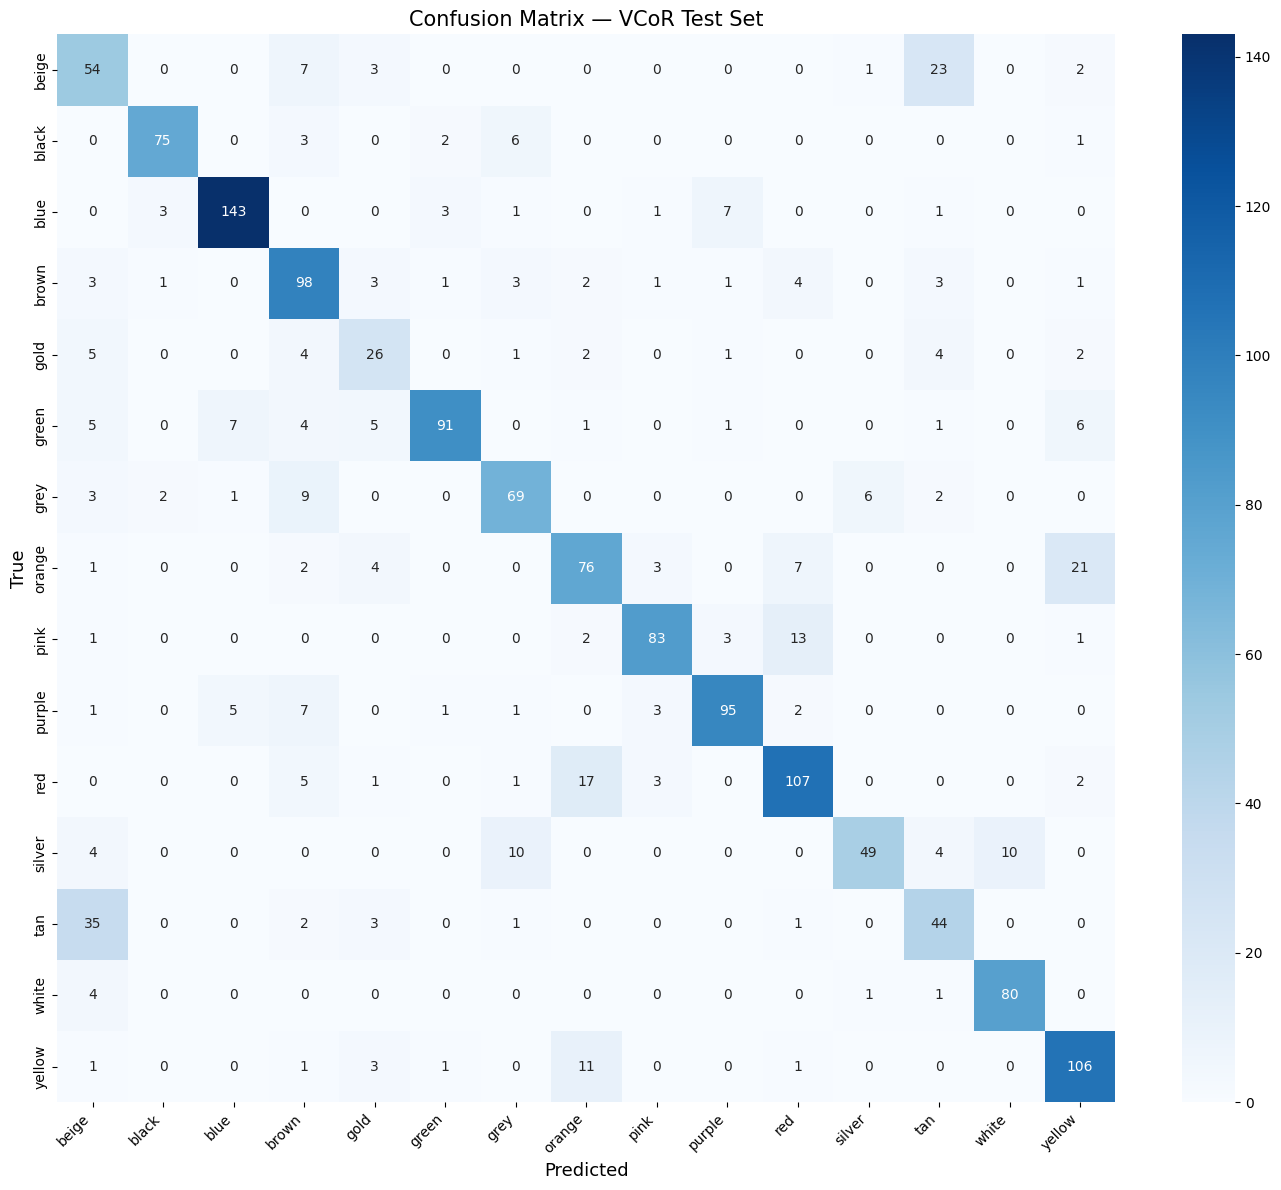

In [70]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title("Confusion Matrix — VCoR Test Set", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Normalized confusion matrix

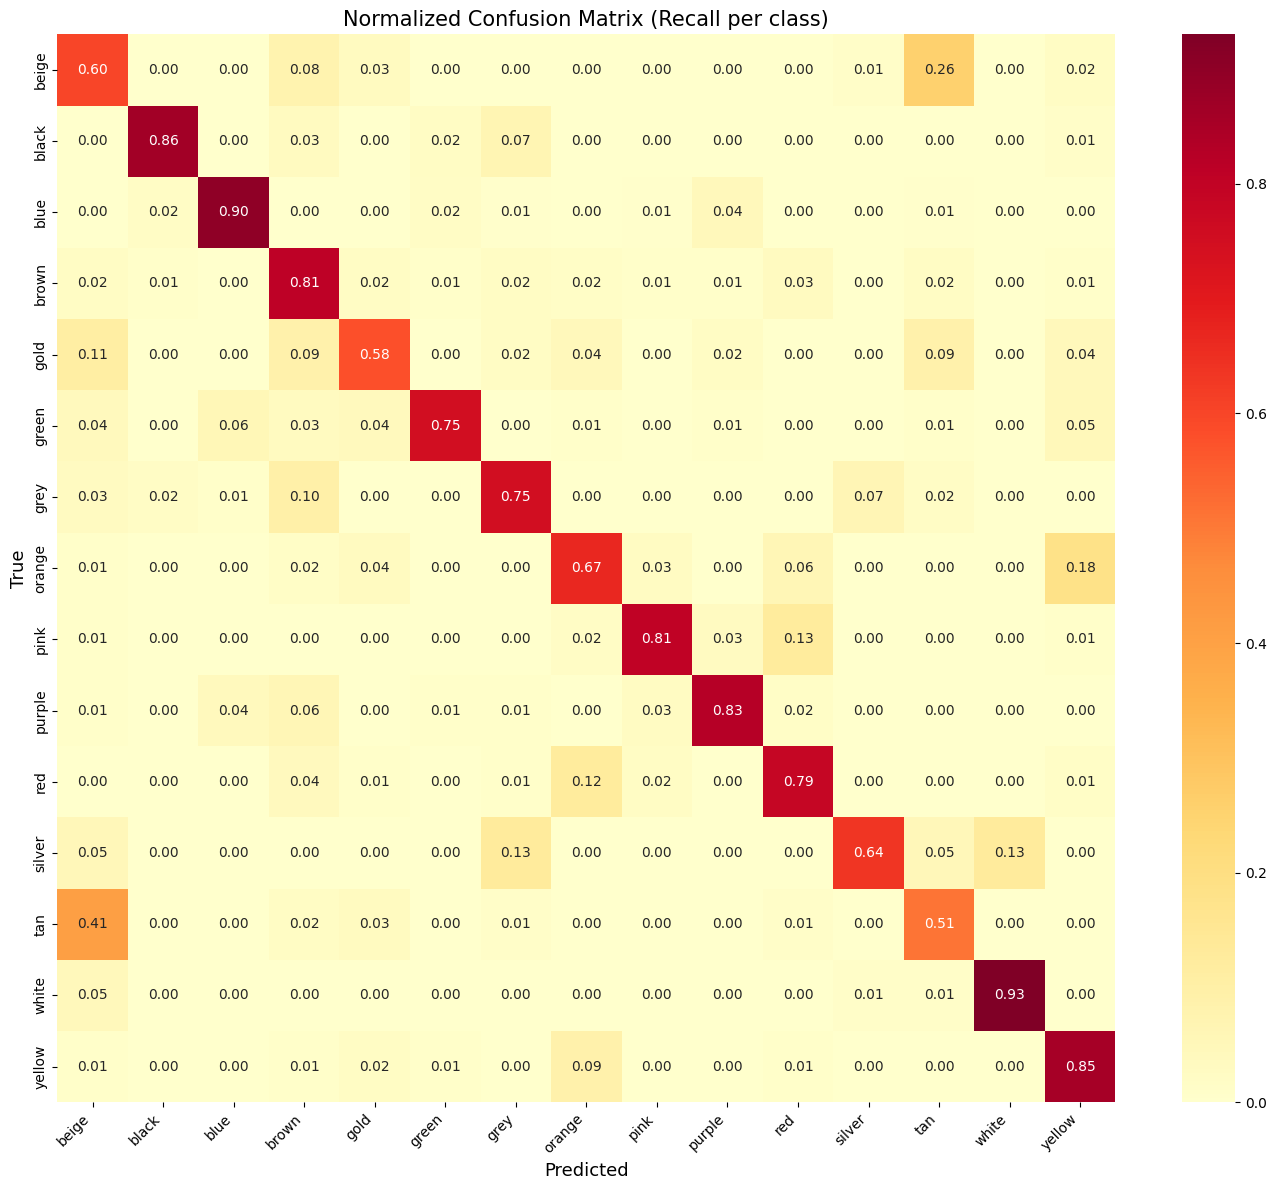

In [71]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title("Normalized Confusion Matrix (Recall per class)", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

per class F1 barchart

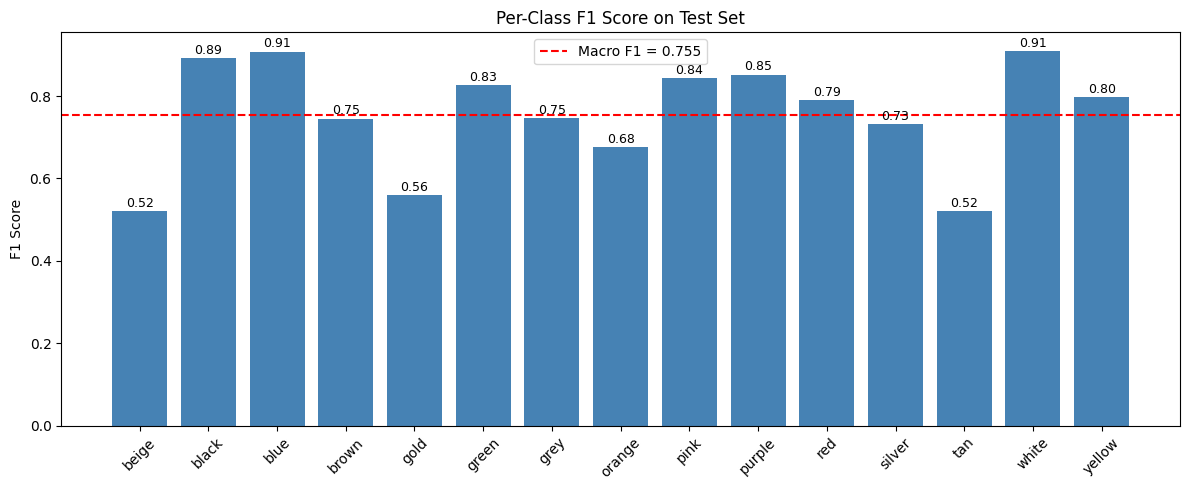

In [72]:
from sklearn.metrics import f1_score as f1_per_class

per_class_f1 = f1_score(y_true, y_pred, average=None)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, per_class_f1, color="steelblue")
ax.axhline(y=macro_f1, color="red", linestyle="--", label=f"Macro F1 = {macro_f1:.3f}")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Score on Test Set")
ax.legend()
ax.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Sample correct and wrong predictions

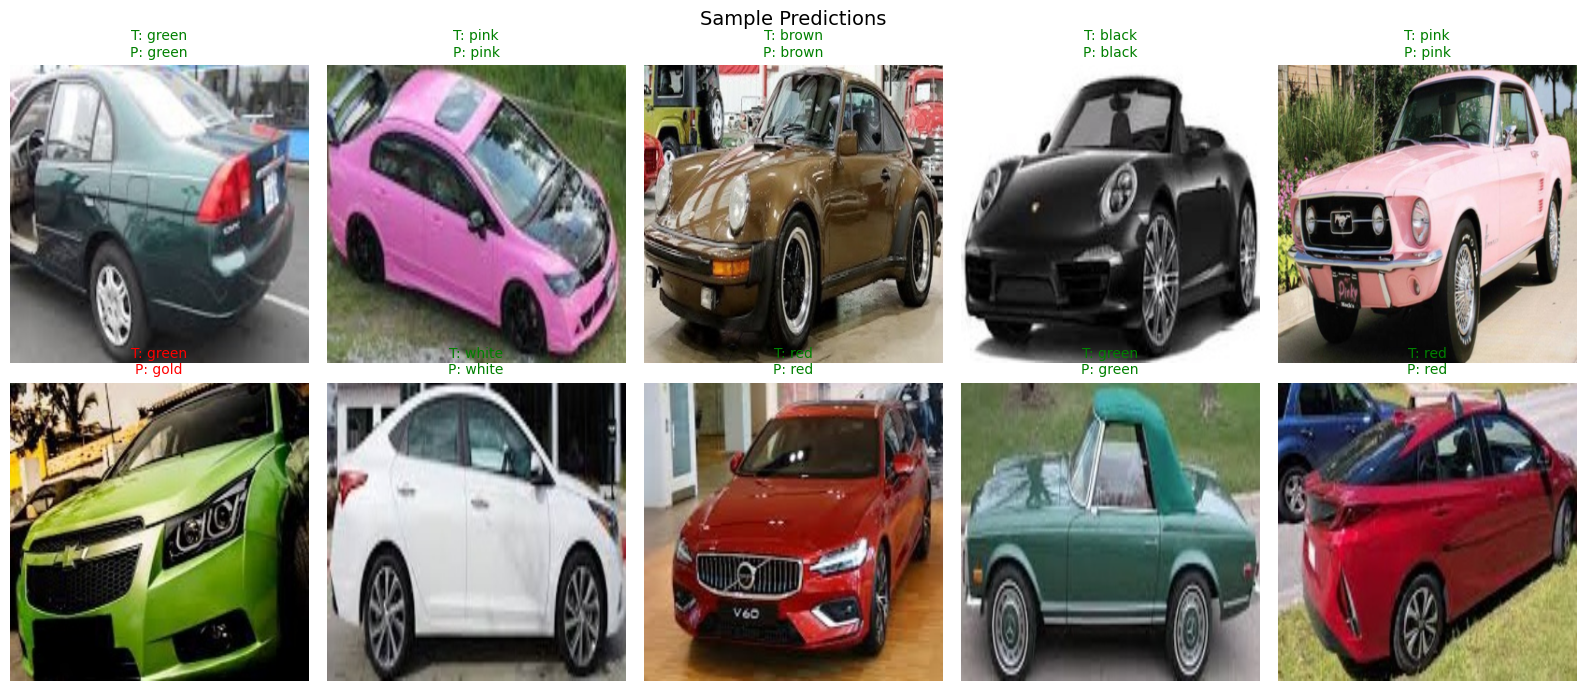

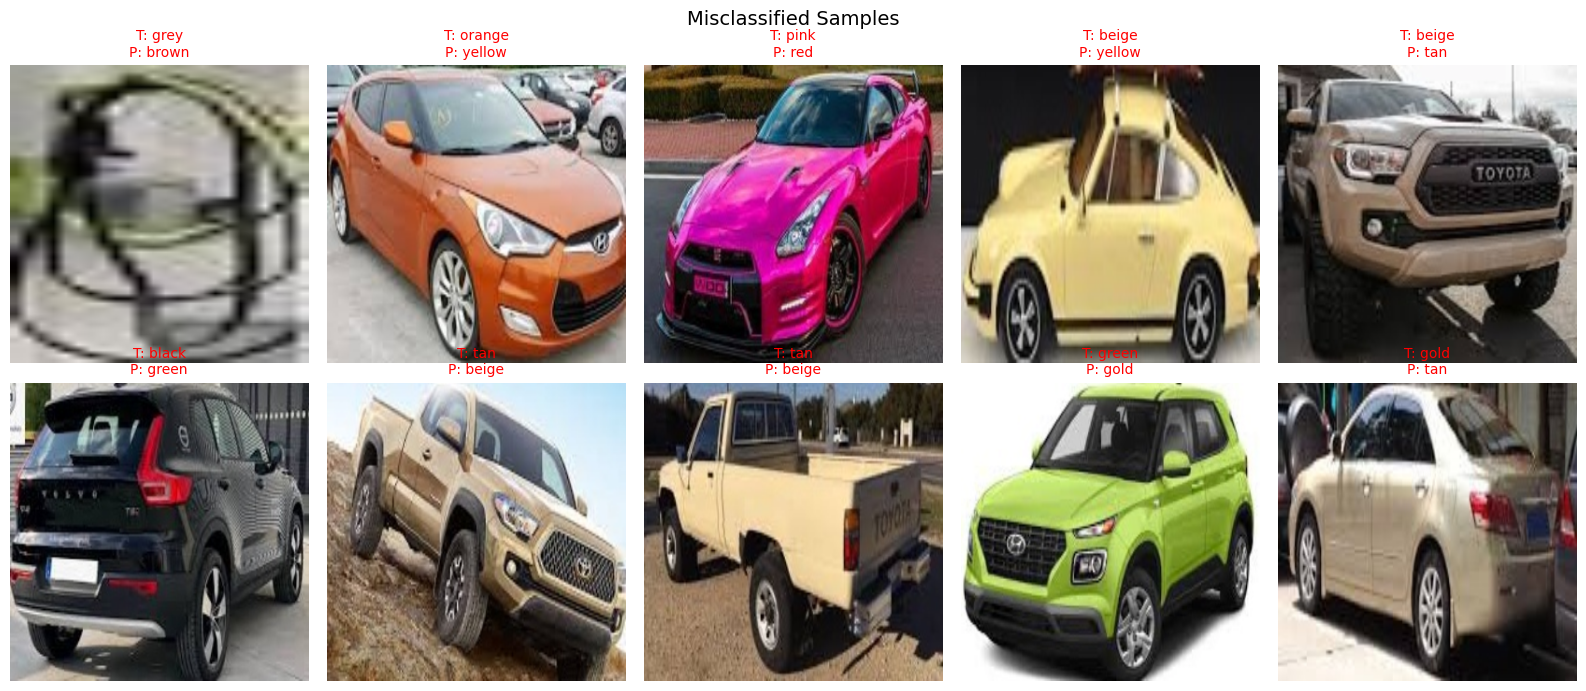

In [83]:
def show_predictions(dataset, y_true, y_pred, class_names, n=10, only_wrong=False):
    indices = np.arange(len(y_true))
    if only_wrong:
        indices = indices[y_true != y_pred]
        title = "Misclassified Samples"
    else:
        title = "Sample Predictions"
    
    selected = np.random.choice(indices, min(n, len(indices)), replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    for i, idx in enumerate(selected):
        img, _ = dataset[idx]
        # Denormalize for visualization
        img = img * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + \
              torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img = img.permute(1, 2, 0).clamp(0, 1).numpy()
        
        ax = axes[i // 5, i % 5]
        ax.imshow(img)
        color = "green" if y_true[idx] == y_pred[idx] else "red"
        ax.set_title(f"T: {class_names[y_true[idx]]}\n"
                     f"P: {class_names[y_pred[idx]]}", color=color, fontsize=10)
        ax.axis("off")
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# Show correct & wrong predictions
show_predictions(test_dataset, y_true, y_pred, CLASS_NAMES, n=10, only_wrong=False)
show_predictions(test_dataset, y_true, y_pred, CLASS_NAMES, n=10, only_wrong=True)

### Onnx export

In [75]:
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

full_model.eval()
torch.onnx.export(
    full_model,
    dummy_input,
    "vcor_yolo_cls.onnx",
    opset_version=17,
    input_names=["images"],
    output_names=["output"],
    dynamic_axes={"images": {0: "batch"}, "output": {0: "batch"}},
)
print("Exported to vcor_yolo_cls.onnx")

# Save class names for later use
with open("vcor_labels.txt", "w") as f:
    for name in CLASS_NAMES:
        f.write(name + "\n")
print("Saved class names to vcor_labels.txt")

/tmp/ipykernel_3442/4285357340.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0307 21:02:35.609000 3442 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0307 21:02:35.828000 3442 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, al

[torch.onnx] Obtain model graph for `ClassificationModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClassificationModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/home/n03an/code/deepstream_custom_parser/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/n03an/code/deepstream_custom_parser/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/home/n03an/code/deepst

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 77 of general pattern rewrite rules.
Exported to vcor_yolo_cls.onnx
Saved class names to vcor_labels.txt
